<a href="https://colab.research.google.com/github/Kaori-Sensei/Data-Analysis/blob/main/PROYECTO_FINAL_MACHINE_LEARNING_AND_DATA_SCIENCE_17_Mar_2023_ARO_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROYECTO APLICADO**
## **Analisis espacial y exploratorio de la incidencia de *Aeneolamia varia (Salivazo)*** **en cultivos comerciales de caña de azúcar empleando herramientas de ciencia de datos**

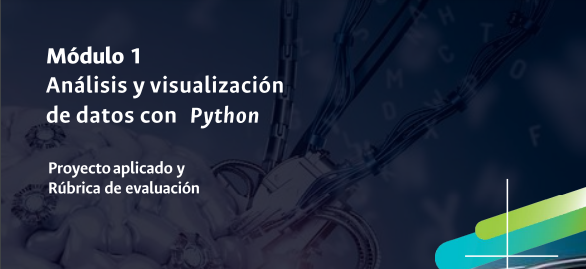

## **Integrantes**

#### Luis Alberto Castillo Sanabria
#### Armando Rojas Orbes
#### Salomon Palacios Suarez

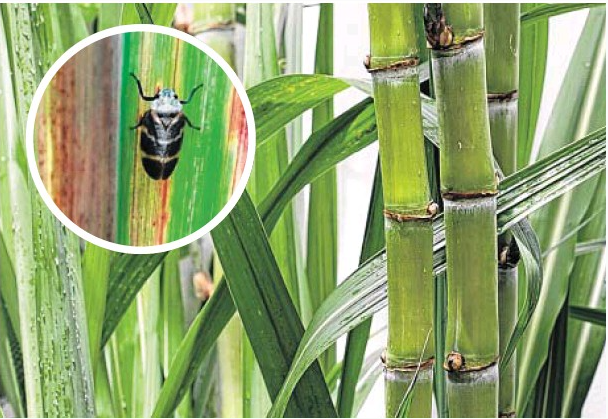

Importación de las librerias de Python para el proyecto

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuraciones de Matplotlib
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
!pip install --upgrade xlrd    # Paquete necesario para cargar archivos de excel usando las versiones más recientes de pandas
# Librería de datos geoespaciales GeoPandas.
!pip install -U geopandas
!pip install -U rtree mapclassify fiona pyproj
!sudo apt install libspatialindex-dev

import geopandas as gpd         # Librería de datos geoespaciales GeoPandas.
import shapely                  # Librería de manipulación de objetos geométricos.
from shapely.geometry import *  # Herramientas para manipulación geométrica.


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libspatialindex-dev is already the newest version (1.9.3-2).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


# **1. ENTENDIMIENTO DEL NEGOCIO**
---
En este estudio vamos a analizar la incidencia de la plaga salivazo en cultivos comerciales de caña de azúcar del inegio de caña san carlos de aproximadamente 6000 ha, la plaga a evaliar es Aeneolamia varia mas conocido como Salivazo que es una Hemiptera de la familia Cercopidae. Se tomaron datos entre 2009 y 2019 en Tuluá, Valle del Cauca, Colombia. Se emplearon herramientas de análisis y modelación espacial basada en ciencia de datos para evaluar la agregación y distribución espacial de la presencia del insecto en los lotes comerciales evaluados; para este fin se empleó estadística descriptiva, exploratoria y estadística inferencial.


Para el análisis exploratorio se caracterizó la influencia de diferentes variables climáticas sobre la incidencia de ninfas y adultos por tallos presentes en los lotes del cultivo. Adicionalmente, se evaluó la relación entre los parámetros edáficos del suelo con la abundancia de ninfas (salivas) y adultos.

Se determinó la distribución y agregación espacial interanual en los lotes muestreados, y se estableció una superficie del nivel de afectación; los efectos estimados del clima y diferentes parámetros edáficos condujeron a diferentes conclusiones. Este notebook sugiere que los contenidos de fósforo, manganeso, hierro, la capacidad de intercambio catiónico, así como la edad de evaluación de la caña y próximo corte están asociadas con un mayor riesgo de incidencia de adultos y ninfas en el cultivo.


El fin de la aplicación de estas herramientas de análisis es conocer como se comporta la distribución poblacional de la plaga y su correlación con el como la precipitación y la humedad relativa en la zona de estudio del Valle del Cauca, en base a esto se toman decisión de manejo integrado a nivel agronómico, por ejemplo en qué momento es bueno aplicar plaguicida, esto según el umbral de acción de la plaga en el cultivo de caña, el umbral de acción es de 0,2 ninfas o adultos por tallo, en este orden de ideas esta información también nos permite tomar decisiones de cuando no se debe realizar la aplicacion, tambien nos da información de los meses en donde hay mayor proliferación de la plaga según el comportamiento de la precipitación y la humedad relativa.





#### A continuacion una imagen de Gogole maps con la ubiacion del ingenio azucarero San Carlos sobre el cual se està haciendo el estudio

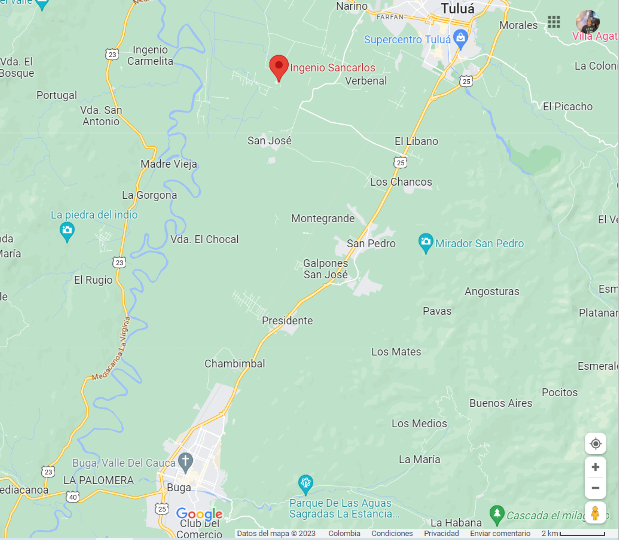

## **a) Objetivo del negocio**
---

### Establecer nuevas herramientas para la protección en el cultivo de caña de azúcar bajo la afectación por Salivazo.

## **b) Objetivo del proyecto**
---


### Examinar datos espaciales de incidencia de salivas por tallo, adultos por tallo, junto con parámetros edáficos y variables climáticas en diferentes lotes con puntos de muestreo aleatorizados entre el año 2009 y 2019.


## **C) Planeación del Proyecto**
---

### - El muestreo de *Aeneolamia varia* fue totalmente aleatorizado en 6000 Ha de cultivo comercial de caña de azúcar distribuido en lotes del ingenio san carlos en el Departamento de Valle del Cauca.

### - La precipitación y la humedad relativa (máxima, mínima y media) fueron extraídas a partir de la estación meteorologica experimental de Buga.

### - A partir de los estudios de suelo efectuados a lo largo de tiempo en los lotes para el establecimiento del cultivo, se extrajeron características como PH, fosforo (ppm), zinc (ppm), hierro (ppm), Mn (ppm), cobre (ppm), boro (ppm), porcentaje de materia orgánica, capacidad de intercambio catiónico, entre otros.

### - La distribución espacial fue analizada a partir de estadistica exploratoria e inferencial, correlacion de las variables del muestreo con variables de clima y edaficas, El número de ninfas y adultos por mes y por año para los datos colectados entre 2009 y 2019 fue comparado con los datos de las variables climáticas a partir de gráficos exploratorios.

# **2.ENTENDIMIENTO DE LOS DATOS**
---
#### A continuacion se hace una lsita de las principales fuentes de los data set, la mayorìa de la informaciòn fue tomada de la plataforma de datos abiertos GOV.CO.

#### Para reducir el tamaño de los archivos CSV se filtro por el departamento del "Valle del Cauca" y por el municipio de BUGA que es el punto de medició mas cercano a lugar de los cultivos.

| Num - Nombre Dataset  | Desripción Información	| Años de información |
| --- | --- | --- |
| 01 - 0_Precipitacion_BUGA.CSV | 	Precipitación en mm en Municipio de BUGA, cada 10min | 2017 a 2021  |
| 02 - 1_Humedad_del_Aire_2_metros BUGA.CSV	| Humedad del aire 2 mt % en Municipio de BUGA, | 2008 a 2021 |
| 03 |	dos 	|  2006 a 2021 |





# **a) Adquisición e integración de Datos**
---
#### La información fue obtenida de dos fuentes principales:

#### *Primer Grupo:** son los datos de la presencia de "Salivazo" en un cultivo de cala de azúcar del ingenio "San Carlos" en el municipio de Tuluá, ingenio ubicado aproximadamente a 2,5km del sur este de Tuluá. Estos datos fueron obtenidos de un proyecto de agricultura sostenible de la faciltad de ciencias agrarias de la universidad nacional de Colombia sede Bogota.

#### **Segundo Grupo** Hace referencia a la información de caracter climatico mas correlacionada con el desarrollo de la plaga, que fue tomada de la plataforma de datos abiertos del Gobierno. Se enfatizo en las variables de precipitacion y humedad relativa.

#### Para reducir el tamaño de los archivos CSV se filtro por el departamento del "Valle del Cauca" y por el municipio de BUGA que es el punto de medició mas cercano a lugar de los cultivos.

https://www.datos.gov.co/

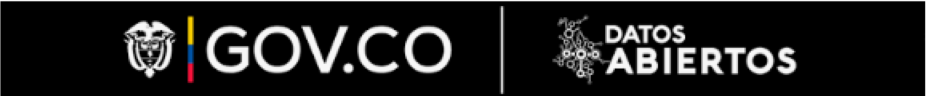

| Num - Nombre Dataset  | Desripción Información	| Años de información |
| --- | --- | --- |
| 01 |	Datos Muetreo plaga 	|  2006 a 2021 |
| 02 - 0_Precipitacion_BUGA.CSV | 	Precipitación en mm en Municipio de BUGA, cada 10min | 2017 a 2021  |
| 03 - 1_Humedad_del_Aire_2_metros BUGA.CSV	| Humedad del aire 2 mt % en Municipio de BUGA, | 2008 a 2021 |


#### Este codigo permite que el notebook este conectado al archivo CSV que se encuentra en drive y que la persona que use el notebbok pueda acceder a los datos desde cualquuier lugar.

#### A continuación se hace la importación de los data set "PRECIPITACION BUGA" desde la carpeta de DRIVE hacia los Notebook.

In [ ]:
### IMPORTACIÒN DEL DATASET DE PRECIPITACION CSV.
# Este codigo permite que el Nootbook se conecte al archivo CSV que se encuentra en el DRIVE y que la persona que use el notebook puede accceder a los datos desde cualquier
# lugar DATOS DE PRECIPITACION "0_Precipitacion_BUGA.csv"
!gdown --id 1CdyWaRJhFm2Xh5djNPr52SAQ1QoFppcz

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CdyWaRJhFm2Xh5djNPr52SAQ1QoFppcz
To: /content/0_Precipitacion_BUGA.csv
100% 83.6M/83.6M [00:00<00:00, 96.8MB/s]


In [ ]:
PRECIPITACION = pd.read_csv('0_Precipitacion_BUGA.csv')

#### A continuación se hace la importación* de los data set "HUMEDAD RELATIVA" desde la carpeta de DRIVE hacia los Notebook.

In [ ]:
### IMPORTACIÒN DEL DATASET DE HUMEDAD RELATIVA CSV.
#URL con dataset de datos abiertos de precipitacion que se encuentra en la carpeta de google Drive
!gdown --id 1KE2YIRnkhGxG1Vz2Wc6u0cPZdNMT1HNt


/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KE2YIRnkhGxG1Vz2Wc6u0cPZdNMT1HNt
To: /content/1_Humedad_del_Aire_2_metros BUGA.csv
100% 12.9M/12.9M [00:00<00:00, 80.3MB/s]


In [ ]:
HUMEDAD = pd.read_csv('1_Humedad_del_Aire_2_metros BUGA.csv')

#### A continuación se hace la importación de los data set "SALIVAZO" desde la carpeta de DRIVE hacia los Notebook. Este data set fue en formato excel.

In [ ]:
### IMPORTACIÒN DEL DATASET DE SALIVAZO XLSX.
#URL con dataset de datos abiertos de precipitacion que se encuentra en la carpeta de google Drive
!gdown --id 19PUVkiAyFsBcpVf5KYV3-XvQUQdi5x0-

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=19PUVkiAyFsBcpVf5KYV3-XvQUQdi5x0-
To: /content/BD_Salivazo.xlsx
100% 1.32M/1.32M [00:00<00:00, 133MB/s]


In [ ]:
BD_SALIVAZO=pd.read_excel('BD_Salivazo.xlsx')

# **b) Análisis exploratorio de datos**
---

### A continuaciòn haremos el análisis exploratorio de los datos, dado que son 3 Data Set Diferentes se hará para cada uno de los data Set, y al finalizar cada Data Set se presetaran las principales observaciones asociadas al análisis.

## **b) 1. PRECIPITACION: Análisis exploratorio de datos: Data set "0_Precipitacion_BUGA.csv"**
---

#### Primero se realizo los de precipitacion con todos los puntos georeferenciados y con unidad de medidad en milimetros por metro cuadrado.

In [ ]:
### IMPORTACION DEL DATASET DE PRECIPITACIONES EN mm de lluvia.
PRECIPITACION.head()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,26095320,240,03/23/2019 11:50:00 AM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
1,26095320,240,09/11/2017 01:10:00 AM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
2,26095320,240,11/11/2017 10:50:00 PM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
3,26095320,240,04/10/2017 04:00:00 AM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
4,26105240,240,03/21/2019 12:20:00 AM,0.1,EL PLACER - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.879111,-76.100556,Precipitacion,mm


In [ ]:
PRECIPITACION.tail()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
656431,2633700150,240,03/13/2023 10:50:00 AM,0.0,GUAYABAL - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.894569,-76.347022,Precipitacion,mm
656432,26095320,240,03/13/2023 12:10:00 AM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
656433,2633700150,240,03/13/2023 01:10:00 PM,0.0,GUAYABAL - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.894569,-76.347022,Precipitacion,mm
656434,26095320,240,03/13/2023 08:20:00 PM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm
656435,26095320,240,03/13/2023 06:20:00 AM,0.0,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Precipitacion,mm


## **Realizamos un analisis de los datos nulos para posteriormente realizar la limpieza de los mismos.**

In [ ]:
# Con le siguiente código se puede ver si hay dato Nullos en el dat set
PRECIPITACION.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656436 entries, 0 to 656435
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CodigoEstacion     656436 non-null  int64  
 1   CodigoSensor       656436 non-null  int64  
 2   FechaObservacion   656436 non-null  object 
 3   ValorObservado     656436 non-null  float64
 4   NombreEstacion     656436 non-null  object 
 5   Departamento       656436 non-null  object 
 6   Municipio          656436 non-null  object 
 7   ZonaHidrografica   656436 non-null  object 
 8   Latitud            656436 non-null  float64
 9   Longitud           656436 non-null  float64
 10  DescripcionSensor  656436 non-null  object 
 11  UnidadMedida       656436 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 60.1+ MB


## **Eliminacion de datos vacios**

## **Se utilizo la funcion .dropna para la eliminar los datos nulos**.

In [ ]:
# PASO PARA ELIMINAR DATOS VACIOS
# No habian datos vacíos pues se ve que se teienen la misma cantodad de filas
PRECIPITACION=PRECIPITACION.dropna()
PRECIPITACION.shape

(656436, 12)

## **Se utilizo la funcion .duplicates para la eliminar los datos repetidos**.

In [ ]:
# establecer un método para eliminar duplicados
# Se eleiminaron 19.784 Duplicados
PRECIPITACION=PRECIPITACION.drop_duplicates()
PRECIPITACION.shape

(636652, 12)

## **Es importante validar que no queden datos duplicados**

In [ ]:

# se valida que no queden duplicados
PRECIPITACION.duplicated().sum()

0

### Agrupando por el nombre de la estaciòn metereològica se obseva que se descargaron datos de 4 estaciones metereológicas, para ser consistentes con el data set de Humedad Relativa

###se considera necesario el filtrar por la estación "EL VINCULO - AUT " que es la misma estación que tiene los datos de Humedad Relativa

In [ ]:
# Agrupando por el nombre de la estaciòn metereològica se obseva que se descargaron datos de 4 estaciones metereológicas, para ser consistentes con el data set de Humedad Relativa
# se considera necesario el filtrar por la estación "EL VINCULO - AUT " que es la misma estación que tiene los datos de Humedad Relativa
PRECIPITACION.groupby(['NombreEstacion']).size()

NombreEstacion
EL PLACER - AUT            169653
EL VINCULO - AUT           258795
GUACHAL PALMASECA - AUT     92440
GUAYABAL - AUT             115764
dtype: int64

## **ACTUALIZACION FORMATO DEL CAPO FECHA y FILTRADO DE LA ESTACION METEREOLOGICA**

In [ ]:
# Formula para convertir la columna 'FechaObservacion' que està como u  string a formato fecha
PRECIPITACION["Fecha"]=pd.to_datetime(PRECIPITACION['FechaObservacion'], format="%m/%d/%Y %I:%M:%f %p")
# Se crea la columna de año para poder agrupar
PRECIPITACION["Year"]=PRECIPITACION["Fecha"].dt.year
PRECIPITACION["Month"]=PRECIPITACION["Fecha"].dt.month
PRECIPITACION["Hour"]=PRECIPITACION["Fecha"].dt.hour

In [ ]:
# Cosntrucción del nuevo data set de PRECIPITCION solo con los datos de la estacion "EL VINCULO - AUT"
df_FILTRO_PREC=PRECIPITACION['NombreEstacion']=='EL VINCULO - AUT'
PRECIPITACION_FILTRADO=PRECIPITACION[df_FILTRO_PREC]

## **DATOS LIMPIOS PRECIPITACION**

In [ ]:
PRECIPITACION_FILTRADO.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258795 entries, 0 to 656435
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CodigoEstacion     258795 non-null  int64  
 1   CodigoSensor       258795 non-null  int64  
 2   FechaObservacion   258795 non-null  object 
 3   ValorObservado     258795 non-null  float64
 4   NombreEstacion     258795 non-null  object 
 5   Departamento       258795 non-null  object 
 6   Municipio          258795 non-null  object 
 7   ZonaHidrografica   258795 non-null  object 
 8   Latitud            258795 non-null  float64
 9   Longitud           258795 non-null  float64
 10  DescripcionSensor  258795 non-null  object 
 11  UnidadMedida       258795 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 25.7+ MB


## **Observaciones Data set "0_Precipitacion_BUGA.csv":**
#### 1. El data set tiene **656.436 filas de Datos**, todos los campos tiene igual cantidad de Datos y en general los datos obtenidos de la plataforma de datos abiertos, son datos estructurados.
#### 2. En una primera revisión parecen no haber datos faltantes, sin embargo se oserva que el CSV descargado tiene un volumen de datos mayor al esperado.
#### 3. Los campos codigoEstacion, codigoSensor, Descripción sensor, aparecen como datos numericos enteros, sin embargo estos valores no tiene sentido estadístico, por lo cual se ignoran.
#### 4. Adicionalmente los campos Latitud y longitud aparecen como datos numericos de coma flotante, **pero no tiene sentido realizar análisis estadìstico sobre las mismas.**
#### 5. Se observa que en el campo Nombre estación se presentan datos de **diferentes estaciones metereológicas que aunque están en el municipio de BUGA son datos "Duplicados"** pues vienen de diferentes estaciones metereológicas

HAY QUE MENCIONAR CUALES SON LAS VARIABLES CATEGORICAS y CUALES NUMERICOS, de cada DATASET

## **Algunas observaciones:**
####1. para validar cuantos estaciones metereológicas se estàn observando hacemos una agrupación por estación

## **b) 2. HUMEDAD: Análisis exploratorio de datos: Data set "1_Humedad_del_Aire_2_metros BUGA.csv"**
---

## **DATOS LIMPIOS DE HUMEDAD RELATIVA**

In [ ]:
HUMEDAD.head()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,26095320,27,12/04/2017 05:00:00 PM,61,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
1,26095320,27,05/19/2016 09:00:00 AM,65,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
2,26095320,27,07/06/2009 05:00:00 PM,66,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
3,26095320,27,04/01/2013 12:00:00 PM,56,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
4,26095320,27,03/21/2008 08:00:00 AM,83,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%


In [ ]:
HUMEDAD.tail()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
95517,26095320,27,03/13/2023 06:00:00 PM,99,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
95518,26095320,27,03/13/2023 10:00:00 AM,96,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
95519,26095320,27,03/13/2023 03:00:00 PM,76,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
95520,26095320,27,03/13/2023 05:00:00 PM,89,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%
95521,26095320,27,03/13/2023 02:00:00 PM,71,EL VINCULO - AUT,VALLE DEL CAUCA,BUGA,CAUCA,3.834806,-76.300006,Humedad del aire 2 mt,%


In [ ]:
HUMEDAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95522 entries, 0 to 95521
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CodigoEstacion     95522 non-null  int64  
 1   CodigoSensor       95522 non-null  int64  
 2   FechaObservacion   95522 non-null  object 
 3   ValorObservado     95522 non-null  int64  
 4   NombreEstacion     95522 non-null  object 
 5   Departamento       95522 non-null  object 
 6   Municipio          95522 non-null  object 
 7   ZonaHidrografica   95522 non-null  object 
 8   Latitud            95522 non-null  float64
 9   Longitud           95522 non-null  float64
 10  DescripcionSensor  95522 non-null  object 
 11  UnidadMedida       95522 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 8.7+ MB


## **Eliminacion de datos vacios**

## **Se utilizo la funcion .dropna para la eliminar los datos nulos**.

In [ ]:
# PASO PARA ELIMINAR DATOS VACIOS
HUMEDAD=HUMEDAD.dropna()
HUMEDAD.shape

(95522, 12)

## **Se utilizo la funcion .duplicates para la eliminar los datos repetidos**.

In [ ]:
# establecer un método para eliminar duplicados
# Se eliminaron 894 duplicados
HUMEDAD=HUMEDAD.drop_duplicates()
HUMEDAD.shape

(94658, 12)

## **Es importante validar que no queden datos duplicados**

In [ ]:
# se valida que no queden duplicados
HUMEDAD.duplicated().sum()

0

## **Se agrupa por la estacion EL VINCULO**.

In [ ]:
HUMEDAD.groupby(['NombreEstacion']).size()

NombreEstacion
EL VINCULO - AUT    94658
dtype: int64

In [ ]:
HUMEDAD['NombreEstacion'].value_counts()

NombreEstacion
EL VINCULO - AUT    94658
Name: count, dtype: int64

In [ ]:
# Formula para convertir la columna 'FechaObservacion' que està como u  string a formato fecha
HUMEDAD["Fecha"]=pd.to_datetime(HUMEDAD['FechaObservacion'], format="%m/%d/%Y %I:%M:%f %p")
# Se crea la columna de año para poder agrupar
HUMEDAD["Year"]=HUMEDAD["Fecha"].dt.year
HUMEDAD["Month"]=HUMEDAD["Fecha"].dt.month
HUMEDAD["Hour"]=HUMEDAD["Fecha"].dt.hour

### **b) 3. MUESTRAS SALIVAZO: Análisis exploratorio de datos: Data set "1_Humedad_del_Aire_2_metros BUGA.csv"**
---

In [ ]:
BD_SALIVAZO.head()

,FECHA-EVAL,Year,Month,SUERTE,AREA HAS,Tallos en Suerte,VARIEDAD,PROX-CORTE,tallos_m,salivas,adultos,salivas_tallo,adultos_tallo,Longitud,Latitud,Fe_ppm,Mn_ppm,P_ppm,CIC
0,2009-10-02,2009,10,A310,5.52,662400,CC8592,2,14.083333,0.0,0.0,0.0,0.0,-76.289766,4.062187,5.27,56.40,9.80,34.400000
1,2009-10-02,2009,10,A207,2.06,247200,CC8592,11,15.600000,0.0,0.0,0.0,0.0,-76.291523,4.085366,2.59,54.29,31.55,41.400000
2,2009-10-02,2009,10,A212A,10.79,1294800,CC8592,5,16.875000,0.0,0.0,0.0,0.0,-76.290585,4.065812,5.83,71.57,20.64,11.920089
3,2009-10-03,2009,10,A315D,12.95,1554000,CC8592,2,19.583333,0.0,0.0,0.0,0.0,-76.289646,4.055869,3.37,56.99,13.84,35.400000
4,2009-10-03,2009,10,A318A,6.96,835200,V7151,2,32.466667,0.0,0.0,0.0,0.0,-76.289313,4.084994,37.21,54.92,17.78,35.790000


In [ ]:
BD_SALIVAZO.tail()

,FECHA-EVAL,Year,Month,SUERTE,AREA HAS,Tallos en Suerte,VARIEDAD,PROX-CORTE,tallos_m,salivas,adultos,salivas_tallo,adultos_tallo,Longitud,Latitud,Fe_ppm,Mn_ppm,P_ppm,CIC
12309,2019-01-18,2019,1,CR12B,9.24,1108800,CC05-430,1,15.352941,0.000000,0.000000,0.000000,0.000000,-76.270031,4.023651,8.00,53.50,12.90,25.40000
12310,2019-01-18,2019,1,BA51E,2.93,351600,CC011940,1,14.700000,0.000000,0.000000,0.000000,0.000000,-76.276418,4.046534,3.21,47.50,42.10,24.20000
12311,2019-01-19,2019,1,LP03,8.99,1078800,CC011940,3,30.258065,0.225806,1.322581,0.007463,0.043710,-76.257842,4.041716,3.39,89.84,126.81,26.05000
12312,2019-01-19,2019,1,AR02,6.69,802800,CC11-600,1,24.000000,0.000000,0.200000,0.000000,0.008333,-76.285268,4.033881,52.05,84.20,17.46,19.45000
12313,2019-01-19,2019,1,A109A,4.96,595200,CC01746,5,29.350000,0.000000,0.000000,0.000000,0.000000,-76.293419,4.086185,7.22,76.63,16.40,14.94777


In [ ]:
BD_SALIVAZO.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12314 entries, 0 to 12313
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   FECHA-EVAL        12314 non-null  datetime64[ns]
 1   Year              12314 non-null  int64         
 2   Month             12314 non-null  int64         
 3   SUERTE            12314 non-null  object        
 4   AREA HAS          12312 non-null  float64       
 5   Tallos en Suerte  12314 non-null  int64         
 6   VARIEDAD          12314 non-null  object        
 7   PROX-CORTE        12314 non-null  int64         
 8   tallos_m          12313 non-null  float64       
 9   salivas           12314 non-null  float64       
 10  adultos           12314 non-null  float64       
 11  salivas_tallo     12314 non-null  float64       
 12  adultos_tallo     12314 non-null  float64       
 13  Longitud          12314 non-null  float64       
 14  Latitud           1231

## **Eliminacion de datos vacios**

## **Se utilizo la funcion .dropna para la eliminar los datos nulos**.

In [ ]:
# PASO PARA ELIMINAR DATOS VACIOS
BD_SALIVAZO=BD_SALIVAZO.dropna()
BD_SALIVAZO.shape

(12311, 19)

## **Eliminacion de datos duplicados**

## **Se utilizo la funcion .duplicates para la eliminar los datos nulos**.

In [ ]:
# establecer un método para eliminar duplicados
# Se eliminaron 894 duplicados
BD_SALIVAZO=BD_SALIVAZO.drop_duplicates()
BD_SALIVAZO.shape

(12311, 19)

## **Es importante validar que no queden datos duplicados**


In [ ]:
# se valida que no queden duplicados
BD_SALIVAZO.duplicated().sum()

0

## **DATOS LIMPIOS BD_SALIVAZO**

In [ ]:
BD_SALIVAZO

,FECHA-EVAL,Year,Month,SUERTE,AREA HAS,Tallos en Suerte,VARIEDAD,PROX-CORTE,tallos_m,salivas,adultos,salivas_tallo,adultos_tallo,Longitud,Latitud,Fe_ppm,Mn_ppm,P_ppm,CIC
0,2009-10-02,2009,10,A310,5.52,662400,CC8592,2,14.083333,0.000000,0.000000,0.000000,0.000000,-76.289766,4.062187,5.27,56.40,9.80,34.400000
1,2009-10-02,2009,10,A207,2.06,247200,CC8592,11,15.600000,0.000000,0.000000,0.000000,0.000000,-76.291523,4.085366,2.59,54.29,31.55,41.400000
2,2009-10-02,2009,10,A212A,10.79,1294800,CC8592,5,16.875000,0.000000,0.000000,0.000000,0.000000,-76.290585,4.065812,5.83,71.57,20.64,11.920089
3,2009-10-03,2009,10,A315D,12.95,1554000,CC8592,2,19.583333,0.000000,0.000000,0.000000,0.000000,-76.289646,4.055869,3.37,56.99,13.84,35.400000
4,2009-10-03,2009,10,A318A,6.96,835200,V7151,2,32.466667,0.000000,0.000000,0.000000,0.000000,-76.289313,4.084994,37.21,54.92,17.78,35.790000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12309,2019-01-18,2019,1,CR12B,9.24,1108800,CC05-430,1,15.352941,0.000000,0.000000,0.000000,0.000000,-76.270031,4.023651,8.00,53.50,12.90,25.400000
12310,2019-01-18,2019,1,BA51E,2.93,351600,CC011940,1,14.700000,0.000000,0.000000,0.000000,0.000000,-76.276418,4.046534,3.21,47.50,42.10,24.200000
12311,2019-01-19,2019,1,LP03,8.99,1078800,CC011940,3,30.258065,0.225806,1.322581,0.007463,0.043710,-76.257842,4.041716,3.39,89.84,126.81,26.050000
12312,2019-01-19,2019,1,AR02,6.69,802800,CC11-600,1,24.000000,0.000000,0.200000,0.000000,0.008333,-76.285268,4.033881,52.05,84.20,17.46,19.450000


# **c) Descripciones Generales**
---

#### A continuacion se presenta la descripciòn de los data set usados en el proyecto

#### La tabla Precipitación contiene un análisis exploratorio de datos relacionados con la medición de la precipitación en la ciudad de Buga :

| Variable | Definición	| Valores |
| --- | --- | --- |
| Códigoestación|Código numérico asignado a cada estación.| Categórica|
| Códigosensor	|Código numérico asignado al sensor . | categórica |
| FechaObservación| Fecha en la cual se realiza la observación. 	|categórica|
|ValorObservado|Lectura tomada de los instrumentos de medición. | Numérica|
| NombreEstación|	Nombre de la estación.	| categórica|
|Departamento|Nombre del departamento donde se realiza la medición|categórica|
|Municipio| Nombre del municipio donde se realiza la medición|categórica|
|ZonaHidrográfica|Nombre de la zona hidrográfica en Colombia| categórica|
|Latitud| medida en grados de latitu|categórica|
|Longitud| Expresa la distancia angular entre un punto dado en la superficie terrestre y el meridiano tomado como 0 grados|categórica|
|DescripciónSensor|precipitaciones| categórica|

#### La tabla HUMEDAD contiene un análisis


#### exploratorio de datos relacionados con la medición de la humedad del aire en la ciudad de Buga :

| Variable | Definición	| Valores |
| --- | --- | --- |
| Códigoestación|Código numérico asignado a cada estación.| Categórica|
| Códigosensor	|Código numérico asignado al sensor . | categórica |
| FechaObservación| Fecha en la cual se realiza la observación. 	|categórica|
|ValorObservado|Lectura tomada de los instrumentos de medición. | Numérica|
| NombreEstación|	Nombre de la estación.	| categórica|
|Departamento|Nombre del departamento donde se realiza la medición|categórica|
|Municipio| Nombre del municipio donde se realiza la medición|categórica|
|ZonaHidrográfica|Nombre de la zona hidrográfica en Colombia| categórica|
|Latitud| medida en grados de latitu|categórica|
|Longitud| Expresa la distancia angular entre un punto dado en la superficie terrestre y el meridiano tomado como 0 grados|categórica|
|DescripciónSensor|humedad del aire| categórica|
|UnidadMedida|valor porcentual|categórica|

#### La base de datos BD_SALIVAZO, contiene información acerca del muestreo realizado para determinar la incidencia de salivas por tallo y adultos por tallo, en el cultivo del ingenio San Carlos; durante el periodo comprendido entre los años 2009 - 2019 :

| Variable | Definición	| Valores |
| --- | --- | --- |
| FECHA-EVAL|Contiene la fecha (año) en que se realizó el muestreo.| categórica |
| Year	|  Año en que se realizó el muestreo. | 	categórica
| Month 	| Mes en el cual se realiza el muestreo. 	|Ene=1,Feb=2,Mar=3,Abr=4,May=5,Jun=6,Jul=7,Ago=8,Sep=9,Oct=10,Nov=11,Dic=12.|categórica|
|Suerte|Codigo de caracteres alfanuméricos que se asignan al muestreo. | categorica|
| Area has|	cantidad de hectáreas donde se tomaron las muestras.	| Numérico|
|Tallos en suerte|Contiene la cantidad de tallos donde se toma la muestra|Numérico|
|Variedad| Código alfanumérico asignado a la variedad de tallo|categórica|
|Prox-corte|Número asignado para clasificar el corte desde 1 hasta 20| Numérico|
|Tallos_m| Contiene información acerca del total de tallos muestreados|Numérico|
|Salivas| Cantidad de plaga en etapa de formación (ninfas)|Numérico|
|Adultos|Cantidad de plaga en etapa adulta| Numérico|
|salivas_tallo|Cantidad de plaga en etapa de formación encontrada en el tallo|Numérica|
|Adultos_tallo|Cantidad de plaga en etapa adulta hallada en tallo|Numérico|
|Longitud|Expresa la distancia angular entre un punto dado en la superficie terrestre y el meridiano tomado como 0 grados| categórica|
|Latitud| proporciona la localización deun lugar en sentido norte o sur desde el ecuador|categórica|
|Fe_ppm|cantidad de partes por millón de hierro presente en la muestra| Numérico|
|Mn_ppm|cantidad de partes por millón de Manganeso presente en la muestra|Numérico|

# **d) Análisis Con Estadística Descriptiva**
---
#### Encontramos que desde el año 2009 hasta el 2019 el promedio de precipitacion por dia es de 0.01448 mm y el dato maximo de precipitacion por dia es de 16.600 mm

In [ ]:
# Se realiza el calculo de la estadística descriptiva solo a la columna 'ValorObservado' que es la columna donde tiene sentido estadístico realizar el cálculo
PRECIPITACION['ValorObservado'].describe()

count    636652.000000
mean          0.014482
std           0.190124
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.600000
Name: ValorObservado, dtype: float64

#### En el caso de humedad relativa tomando datos del 2009 al 2019 encontramos que l promedio de humedad por dia es de 74.67% lo cual nos hace entender que el ingenio de caña de azucar es un ambiente bastante humedo.

### Se han presentado registros hasta de 100% de humedad relativa.

In [ ]:
HUMEDAD['ValorObservado'].describe()

count    94658.000000
mean        74.673815
std         23.806283
min          0.000000
25%         59.000000
50%         83.000000
75%         94.000000
max        100.000000
Name: ValorObservado, dtype: float64

#### Se realizo un analisis de estadistica descriptiva de diferentes variables del data se BD_SALIVAZO.

#### Las variables de mayor importancia son "salivas_tallo", "adultos_tallo", y las variable de caracteristicas de suelo como "Fe_ppm", "Mn_ppm", "P_ppm" y la capacidad de intercambio cationico "CIC".

In [ ]:
BD_SALIVAZO.describe()

,FECHA-EVAL,Year,Month,AREA HAS,Tallos en Suerte,PROX-CORTE,tallos_m,salivas,adultos,salivas_tallo,adultos_tallo,Longitud,Latitud,Fe_ppm,Mn_ppm,P_ppm,CIC
count,12311,12311.000000,12311.000000,12311.000000,1.231100e+04,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000,12311.000000
mean,2015-01-18 14:03:41.655430144,2014.532776,6.722525,9.193080,1.103170e+06,3.999594,21.590496,0.206970,0.319876,0.010865,0.015634,-76.258608,4.066898,11.234922,70.463613,42.732735,23.469949
min,2009-10-02 00:00:00,2009.000000,1.000000,0.150000,1.800000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-76.293419,3.985482,0.000000,0.000000,2.300000,0.000000
25%,2012-09-28 00:00:00,2012.000000,4.000000,5.090000,6.108000e+05,2.000000,17.437500,0.000000,0.000000,0.000000,0.000000,-76.277050,4.045596,2.470000,51.470000,13.520000,15.090000
50%,2015-04-17 00:00:00,2015.000000,7.000000,8.410000,1.009200e+06,3.000000,20.000000,0.000000,0.000000,0.000000,0.000000,-76.264166,4.067041,5.890000,68.620000,20.790000,20.000000
75%,2017-08-16 00:00:00,2017.000000,10.000000,12.280000,1.473600e+06,5.000000,23.300000,0.000000,0.187500,0.000000,0.009040,-76.243301,4.089697,14.400000,86.685000,38.350000,27.920000
max,2019-01-19 00:00:00,2019.000000,12.000000,1557.000000,1.868400e+08,20.000000,1307.000000,110.200000,54.400000,3.262626,1.806452,-76.170400,4.239410,237.650000,213.400000,1943.000000,120.780000
std,NaN,2.764615,3.466307,14.864299,1.783716e+06,3.146091,23.418404,1.638017,1.381105,0.074887,0.063540,0.023987,0.028629,18.275866,27.442225,105.321306,12.511933


# **e) Visualización de datos estadísticos**


#### Es importante aclarar que los datos de BD_SALIVAZO de la plaga no cumplen normalidad, puesto que sos datos de presencia ya usencia de la plaga tomados en puntos de muestreo como "Suertes" y estos puntos de muestreo no estan definidos, hay suertes de 1,5 hectareas como tambien hay suertes de 20 hectareas, esta variabilidad en los puntos de muestreo afecta la normalizacion de los datos porque hay mayor probabilidad de ecnontrar salivas y adultos en mas hectareas que en menos.

#### Tambien es importante mencionar la distribucion poblacional de la plaga en el cultivo del año 2009 al 2019 es totalmente independiente y variable.

### **HISTOGRAMAS ADULTOS TALLO**

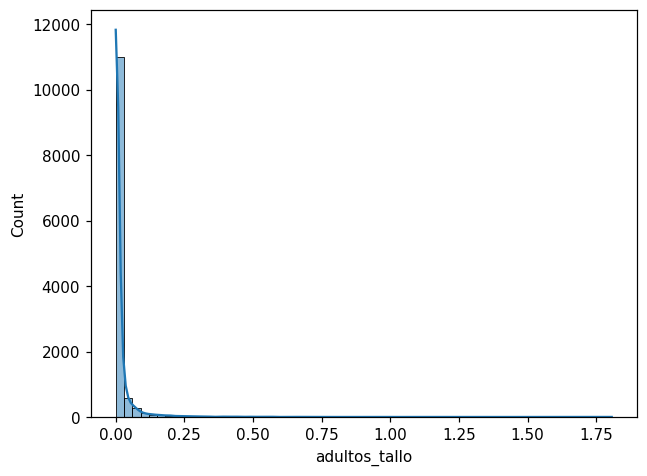

In [ ]:
sns.histplot(BD_SALIVAZO['adultos_tallo'],
             kde=True,
             bins=60);

## **HISTOGRAMAS SALIVAS TALLO**

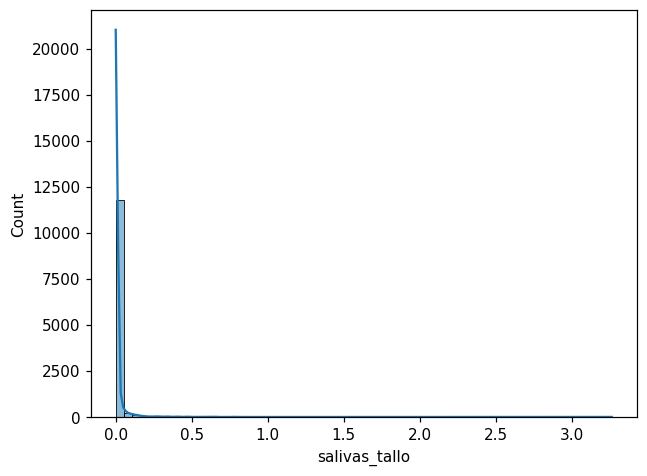

In [ ]:
sns.histplot(BD_SALIVAZO['salivas_tallo'],
             kde=True,
             bins=60);

### Como era de esperarse en los histogramas de "salivas_tallo" y "adultos_tallos" no muestran normalidad y los datoos mas repetidos del monitoreo de plagas desde el 2009 al 2019 son 0.0 , auqnue tambien podemos ver datos de hasta 3 salivas y 1.75 adultos por tallo en un rango menor de 2500 datos de presencia.


METER CONCLUSIONES

# **3. PREPARACION DE LOS DATOS**
---




- #### El siguiente paso es homogenizar los datos de las diferentes tablas: tabla de salivazo, tabla de HUMEDAD y tabla de PRECIPITACION.
- #### Esta homogenización permitirá tener datos CLIMATICOS con datos de la plaga en una misma tabla y estampas de tiempo, para ver la correlación entre las diferentes variables.

In [ ]:
#Se calcula una tabla que agrupe los datos por Año y por mes y calcule el promedio de las columnas "salivas_tallo","adultos_tallo"
SALIVAZO_YEAR_MONTH_AVG=BD_SALIVAZO.groupby(["Year","Month"],as_index=False).agg({"salivas_tallo":"mean","adultos_tallo":"mean"})

In [ ]:
SALIVAZO_YEAR_MONTH_AVG.head(200)

,Year,Month,salivas_tallo,adultos_tallo
0,2009,10,0.000000,0.000000
1,2009,11,0.000000,0.000178
2,2009,12,0.000000,0.001361
3,2010,1,0.000000,0.000751
4,2010,2,0.000000,0.000000
...,...,...,...,...
107,2018,9,0.018674,0.035993
108,2018,10,0.009319,0.013186
109,2018,11,0.023742,0.041213
110,2018,12,0.034024,0.025710


In [ ]:
#Se calcula una tabla que agrupe los datos por Año y por mes y calcule el promedio de la columna "ValorObservado" que tiene la humedad %
HUMEDAD_YEAR_MONTH_AVG=HUMEDAD.groupby(["Year","Month"],as_index=False).agg({"ValorObservado":"mean"})

In [ ]:
#Se Renombran las columna de valor observado por HUMEDAD
HUMEDAD_YEAR_MONTH_AVG.rename(columns={'ValorObservado':'HUMEDAD'},inplace=True)

In [ ]:
HUMEDAD_YEAR_MONTH_AVG.head(200)

,Year,Month,HUMEDAD
0,2005,6,65.018182
1,2005,7,5.000000
2,2005,9,2.000000
3,2005,11,3.000000
4,2005,12,2.500000
...,...,...,...
170,2022,11,59.619048
171,2022,12,71.011628
172,2023,1,70.583514
173,2023,2,71.758427


In [ ]:
#Se calcula una tabla que agrupe los datos por Año y por mes y calcule el promedio de la columna "ValorObservado" que tiene la PRECIPITACION %
PRECIPITACION_FILTRADO_YEAR_MONTH_AVG=PRECIPITACION_FILTRADO.groupby(["Year","Month"],as_index=False).agg({"ValorObservado":"max"})

In [ ]:
#Se Renombran las columna de valor observado por HUMEDAD
PRECIPITACION_FILTRADO_YEAR_MONTH_AVG.rename(columns={'ValorObservado':'PRECIPITACION'},inplace=True)

In [ ]:
#Se Imprime par aver como quedo la agrupacion
PRECIPITACION_FILTRADO_YEAR_MONTH_AVG.head(100)

,Year,Month,PRECIPITACION
0,2016,12,0.0
1,2017,1,8.4
2,2017,2,1.8
3,2017,3,6.2
4,2017,4,12.2
...,...,...,...
63,2022,11,0.0
64,2022,12,0.0
65,2023,1,0.0
66,2023,2,0.0


In [ ]:
#SE HACE EL MERGE INNER de la tabla HUMEDAD y la tabla ALIVAZO (se unen por YEAR y MES) solo quedan las filas en las que hayan datos en las dos tablas para los años y me
DATA_SALIVAZO_HUMEDAD=pd.merge(SALIVAZO_YEAR_MONTH_AVG,HUMEDAD_YEAR_MONTH_AVG,on=('Year','Month'), how='inner')
DATA_SALIVAZO_HUMEDAD=DATA_SALIVAZO_HUMEDAD.sort_values('Year')

In [ ]:
DATA_SALIVAZO_HUMEDAD.head(200)

,Year,Month,salivas_tallo,adultos_tallo,HUMEDAD
0,2009,10,0.000000,0.000000,77.100567
1,2009,11,0.000000,0.000178,76.959091
2,2009,12,0.000000,0.001361,77.128713
13,2010,11,0.013487,0.002184,85.587379
12,2010,10,0.003936,0.002025,80.452693
...,...,...,...,...,...
83,2018,2,0.064709,0.064950,78.801858
82,2018,1,0.038872,0.096113,81.446244
93,2018,12,0.034024,0.025710,77.792633
87,2018,6,0.047046,0.038062,81.718475


In [ ]:
#SE HACE EL MERGE INNER de la tabla SALIVAZO_HUMEDAD y la tabla PRECIPITACION (se unen por YEAR y MES) solo quedan las filas en las que hayan datos en las dos tablas para los años y meses
DATA_SALIVAZO_HUMEDAD_PRECIPITACION=pd.merge(DATA_SALIVAZO_HUMEDAD,PRECIPITACION_FILTRADO_YEAR_MONTH_AVG,on=('Year','Month'), how='inner')
#SE ORDENA POR AÑO
DATA_SALIVAZO_HUMEDAD_PRECIPITACION=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.sort_values('Year',)

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.head(5)

,Year,Month,salivas_tallo,adultos_tallo,HUMEDAD,PRECIPITACION
0,2016,12,0.000279,0.009877,82.988355,0.0
11,2017,1,0.002555,0.016427,82.192034,8.4
10,2017,2,0.013897,0.034202,76.055556,1.8
9,2017,3,0.016166,0.032475,82.122628,6.2
8,2017,4,0.072834,0.104113,82.347953,12.2


In [ ]:
#SE CREA UNA COLUMNA YEAR_MONTH para poder ordenar por fecha los datos, pues en los dataframes anteriores se ordenaba por año pero los meses estaban desordenados
DATA_SALIVAZO_HUMEDAD_PRECIPITACION['YEAR_MONTH']=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.Year*100+DATA_SALIVAZO_HUMEDAD_PRECIPITACION.Month
DATA_SALIVAZO_HUMEDAD_PRECIPITACION=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.sort_values('YEAR_MONTH')
#SE RESETE EL INDICE PORQUE DESPUES DE LOS JOINS SOLO QUEDARON ALGUNOS AÑOS Y MESES CON DATOS.. OTROS NO FUERON TENIDOS EN CUENTA PORQUE FATABAN DATOS DE ALGUNA TABLA ORIGEN
#ASI QUE SE RESETEA PARA PODER GRAFICAR MEJOR CON EL NUEVO INDICE
DATA_SALIVAZO_HUMEDAD_PRECIPITACION=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.reset_index()
DATA_SALIVAZO_HUMEDAD_PRECIPITACION=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.drop(['index'], axis=1)

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.head()

,Year,Month,salivas_tallo,adultos_tallo,HUMEDAD,PRECIPITACION,YEAR_MONTH
0,2016,12,0.000279,0.009877,82.988355,0.0,201612
1,2017,1,0.002555,0.016427,82.192034,8.4,201701
2,2017,2,0.013897,0.034202,76.055556,1.8,201702
3,2017,3,0.016166,0.032475,82.122628,6.2,201703
4,2017,4,0.072834,0.104113,82.347953,12.2,201704


# **4. VISUALIZACION Y ANALISIS DE LOS DATOS**
---




### **a) METODO PAIR PLOT PARA ANALIZAR RAPIDAMENTE LA RELACION ENTRE LAS DIFERENTES VARIABLE DEL DATASET**

Como primer paso vamos a ver todas las posibles relaciones exixtentes entre las diferentes variable del dataset que construimos, para lo cual debemos limpiar el dataset de las variables que no queremos que sean graficadas

In [ ]:
# ELIMINAMOS LAS COLUMNAS QUE NO TIENE VARIABLES DE NUESTRO INTERES PARA FOCALIZARNOS SOLO EN LAS VARIABLES DE INTERES, AÑO, MES y CAMPO AÑO_MES
DATA_SALIVAZO_HUMEDAD_PRECIPITACION_VAL=DATA_SALIVAZO_HUMEDAD_PRECIPITACION.drop(['Year','Month','YEAR_MONTH'], axis=1)

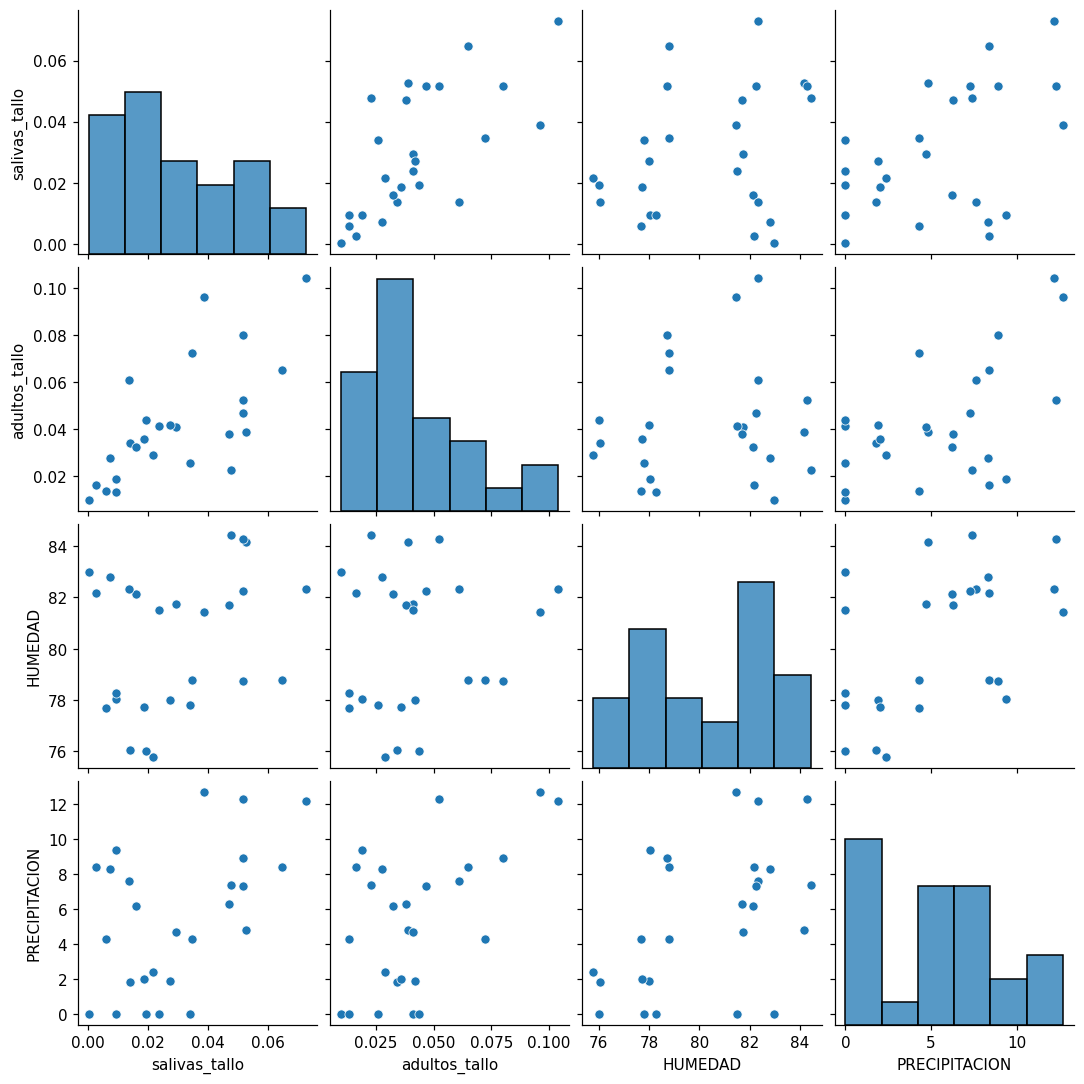

In [ ]:
# Si queremos usar histogramas en la diagonal, usar el parámetro: diag_kind='hist'
sns.pairplot(DATA_SALIVAZO_HUMEDAD_PRECIPITACION_VAL);

## **CONCLUSIONES DEL PAIR PLOT**

En el Grafico anterior de la relacion de las variables se observa:

- Que parece haber cierta correlacion entre las SALIVAS TALLO y Los ADULTOS Tallo (Por lo cual podria ser conveniente calular la correlacion y hacer una regresión)
- Que la Humedad y la precipitacion parecen tambien tener una correlaciòn, aunque mas debil que la de las salivas y adultos.(Tambien seria conveniente calcular la correlacion y hacer una regresion)




### **3) SCATER PLOT Y CORRELACION DE VARIABLES**




**SCATER PLOT Y CORRELACION DE VARIABLES SALIVAS TALLO Vs ADULTOS TALLO**

**CORRELACION DE PEARSON**  (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)

In [ ]:
#CALCULAMOS EL COEFICIENTE DE CORRELACION DE PEARSON (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)
corrrel_SAL_ADU = DATA_SALIVAZO_HUMEDAD_PRECIPITACION['salivas_tallo'].corr(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo']) # Método Pearson por defecto
print(corrrel_SAL_ADU)

0.6797530104856627


/usr/local/lib/python3.9/dist-packages/pandas/plotting/_matplotlib/core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


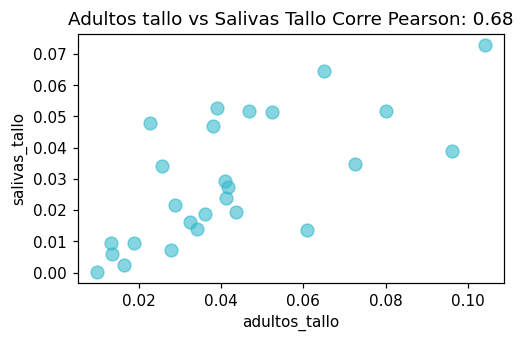

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.plot.scatter('adultos_tallo', 'salivas_tallo', title= f'Adultos tallo vs Salivas Tallo Corre Pearson: {corrrel_SAL_ADU:.2}',
                     s = 70, alpha = 0.6, color = '#35bacc', figsize = (5,3));

**CORRELACION DE SPEARMAN**  (NO REQUIRE ASUNCION DE NORMALIDAD)

In [ ]:
#  CORRELACION DE SPEARMAN (NO REQUIRE ASUNCION DE NORMALIDAD)
# FUNCION QUE USAMOS EN EL MATERIAL DE CLASE PARA CALCULAR LA CORRELACION DE SPEARMAN Y VALIDAR SI DOS VARIABLES ESTÂN CORRELACIONADAS
def correlacion_spearmanr_con_significancia(a, b):
  coef, p = stats.spearmanr(a, b)
  print(f'Coeficiente de correlación de Spearman: {coef:.2f}')

  if p > 0.05:
    print(f'Las muestras no están correlacionadas (no rechazar H0) p = {p:.3f}')
  else:
    print(f'Las muestras están correlacionadas (rechazar H0) p = {p:.3f}')

In [ ]:
correlacion_spearmanr_con_significancia(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['salivas_tallo'], DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo'])

Coeficiente de correlación de Spearman: 0.71
Las muestras están correlacionadas (rechazar H0) p = 0.000


#  **CONCLUSIONES Se observa que la correlacion de SPEARMAN es mayor que el valor de la correlacion de PEARSON**

- Dado que las salivas son la version larva de los adultos, deberìa existir una correlacion entre la cantidad de larvas que con el tiempo se convertiràn en ADULTOS.
- Sólo que las series no estàn sincronizadas en en el mismo tiempo, sino que hay un delay entre las dos seires que en teoria corresponderìa al tiempo en que las salivas se convierten en adultos.

- Otro argumento importante para explicar esta correlacion es el ciclo de vida del insecto, el cual es de 85 dias, muy corto por lo cual el salivazo cumple su cicla de vida en el cultivo de caña donde se reproduce y posteriormente deja huevos en los tallos y hojas de la caña, por eso mismo donde hay adultos hay salivas larva.

### **c) REGRESION LINEAL ADULTOS Vs SALIVAS TALLO**

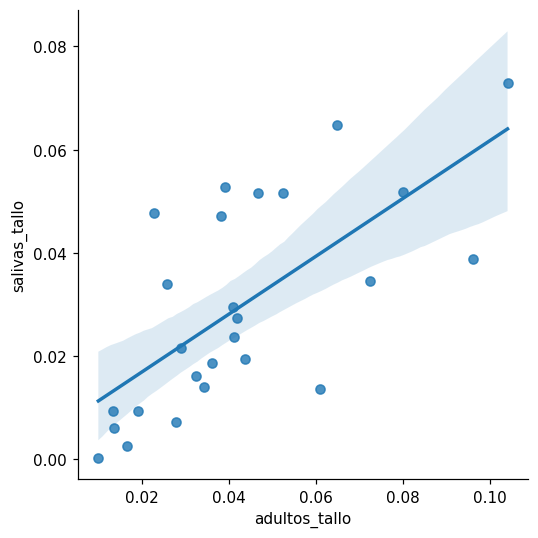

In [ ]:
sns.lmplot(x='adultos_tallo', y='salivas_tallo', data=DATA_SALIVAZO_HUMEDAD_PRECIPITACION);

#### La regresion lineal confirma la alta correlacion entre salivas y adultos.

### **d) HUMEDAD Vs PRECIPITACION**

In [ ]:
#CALCULAMOS EL COEFICIENTE DE CORRELACION DE PEARSON (Asume Normalidad)
corrrel_HUM_PRE = DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION'].corr(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['HUMEDAD']) # Método Pearson por defecto
print(corrrel_HUM_PRE)

0.49419822926161644


/usr/local/lib/python3.9/dist-packages/pandas/plotting/_matplotlib/core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


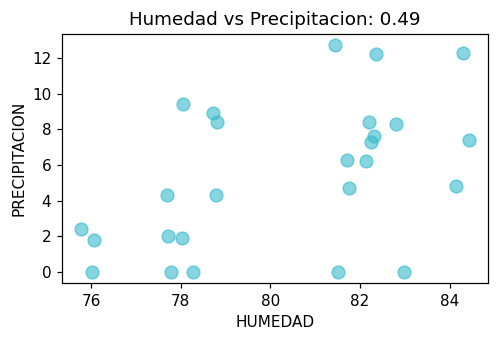

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.plot.scatter('HUMEDAD', 'PRECIPITACION', title= f'Humedad vs Precipitacion: {corrrel_HUM_PRE:.2}',
                     s = 70, alpha = 0.6, color = '#35bacc', figsize = (5,3));

#### Existe una correlacion de casi el 50% entre la humedad y la preciptacion, aun asi es suficiente para creer que estas dos variables climatica pueden ofrcer  un ambiente apto para la proliferacion del insecto

In [ ]:
correlacion_spearmanr_con_significancia(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['HUMEDAD'], DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION'])

Coeficiente de correlación de Spearman: 0.46
Las muestras están correlacionadas (rechazar H0) p = 0.017


#  **CONCLUSIONES PRECIPITACION: Se observa que la correlacion de SPEARMAN es del mismo orden que el valor de la correlacion de PEARSON**

Para el cálculo de la correlacion en el dataset tuvimos que usar la funcion GROUPBY, pues los datos estaban con muestras cada 10 minutos.

- En la agrupación dado que desconocemos el funcionamiento del sensor de precipitacion, no sabemos cual es la mejor forma de agrupar, si por suma de las medidas cada 10min o por el valor maximo del sensor cada 10min.

- Si por ejemplo se usa la suma, y el sensor es un tipo contendor, en el caso en que llueva continuamente y el contenedor no se vacie cada 10min, estaríamos contando 2 veces el volumen de la primera medición, pues en los siguientes 10min el voulmen será la lluvia de los primeros 10min + la lluvia de los anteriores 10min.

- Por esta razon en la costrucción del dataset con las variables climaticas y de plagas usamos el valor MAX (para no comerter el error de conar 2 veces la lluvia)

- Sin embargo usar el máximo tambien podría tener un error intrinsieco asociado a que despues de 2,3 o 6 horas es posibe que el agua se evapore (sobre todo en horas del dia con luz visible), dependiendo de la cantidad de sol que haya y de la humedad relativa del ambiente.

### **e) ADULTOS TALLO Vs HUMEDAD**

In [ ]:
r = DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo'].corr(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['HUMEDAD']) # Método Pearson por defecto
print(r)

0.10556885853765763


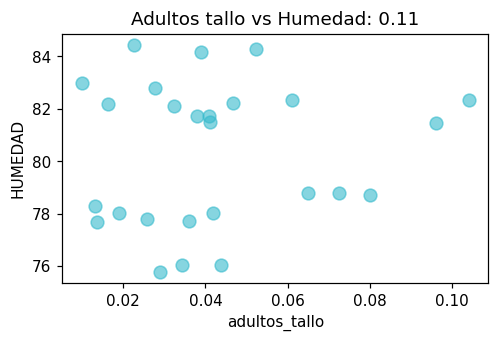

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.plot.scatter('adultos_tallo', 'HUMEDAD', title= f'Adultos tallo vs Humedad: {r:.2}',
                     s = 70, alpha = 0.6, color = '#35bacc', figsize = (5,3));

**CORRELACION DE SPEARMAN**  (NO REQUIRE ASUNCION DE NORMALIDAD)

In [ ]:
correlacion_spearmanr_con_significancia(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo'], DATA_SALIVAZO_HUMEDAD_PRECIPITACION['HUMEDAD'])

Coeficiente de correlación de Spearman: 0.09
Las muestras no están correlacionadas (no rechazar H0) p = 0.662


#### **La humedad tiene minima enfluencia en la proliferacion de los adultos plaga[texto del enlace**

#### No se establecio una correlacion entre humedad y adultos tallo dado a la gran variabilidad de los datos del muestreo en el tiempo, se cree que la humedad relativa no tiene tanta influencia en la proliferacion de la plaga como si lo puede tener la precipitacion.



In [ ]:
BD_SALIVAZO.head()

,FECHA-EVAL,Year,Month,SUERTE,AREA HAS,Tallos en Suerte,VARIEDAD,PROX-CORTE,tallos_m,salivas,adultos,salivas_tallo,adultos_tallo,Longitud,Latitud,Fe_ppm,Mn_ppm,P_ppm,CIC
0,2009-10-02,2009,10,A310,5.52,662400,CC8592,2,14.083333,0.0,0.0,0.0,0.0,-76.289766,4.062187,5.27,56.40,9.80,34.400000
1,2009-10-02,2009,10,A207,2.06,247200,CC8592,11,15.600000,0.0,0.0,0.0,0.0,-76.291523,4.085366,2.59,54.29,31.55,41.400000
2,2009-10-02,2009,10,A212A,10.79,1294800,CC8592,5,16.875000,0.0,0.0,0.0,0.0,-76.290585,4.065812,5.83,71.57,20.64,11.920089
3,2009-10-03,2009,10,A315D,12.95,1554000,CC8592,2,19.583333,0.0,0.0,0.0,0.0,-76.289646,4.055869,3.37,56.99,13.84,35.400000
4,2009-10-03,2009,10,A318A,6.96,835200,V7151,2,32.466667,0.0,0.0,0.0,0.0,-76.289313,4.084994,37.21,54.92,17.78,35.790000


## **f) Analisis de las variedades de caña de azucar sembradas en las 6000 hectareas y su relacion e influencia con la presencia de insectos plaga en estado larval y estado adulto.**

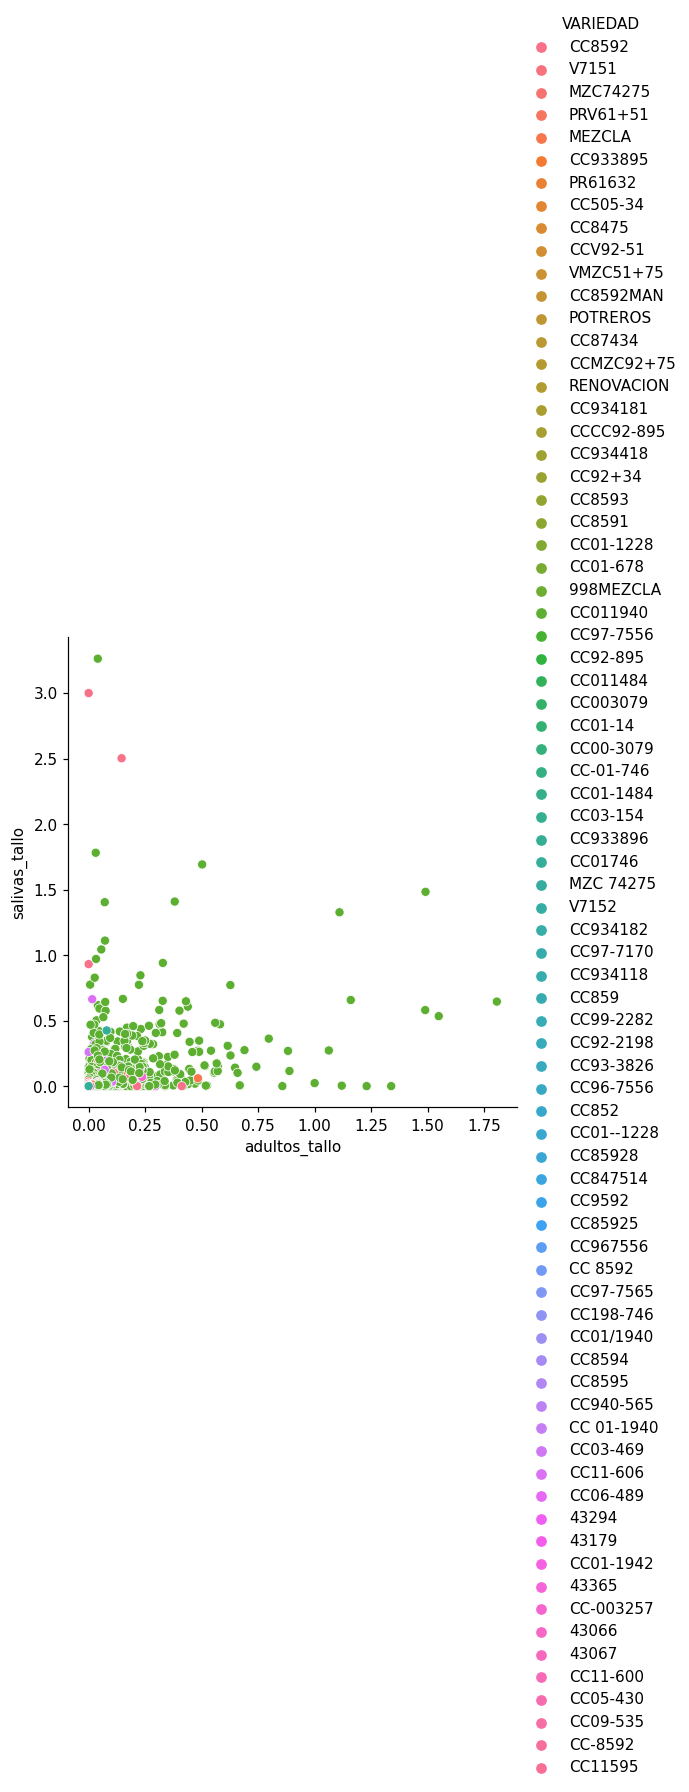

In [ ]:

sns.relplot(data=BD_SALIVAZO, x="adultos_tallo", y="salivas_tallo",hue="VARIEDAD", kind = 'scatter'
            );

####  En este plot podemos observar las variedades que presentaron mayor presencia de salivas tallo segun los conteos.

#### POdemos observar que las variedades de mayor susceptibilidad de ser atacadas por el insecto plaga son las de color verde, que abarcan desde la CC8593 hasta la CC01-14.

**SCATER PLOT Y CORRELACION DE VARIABLES SALIVAS TALLO Vs PRECIPITACION**

**CORRELACION DE PEARSON**  (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)

In [ ]:
#CALCULAMOS EL COEFICIENTE DE CORRELACION DE PEARSON (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)
corrrel_SAL_PRE = DATA_SALIVAZO_HUMEDAD_PRECIPITACION['salivas_tallo'].corr(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION']) # Método Pearson por defecto
print(corrrel_SAL_PRE)

0.4758985648351418


In [ ]:
correlacion_spearmanr_con_significancia(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['salivas_tallo'], DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION'])

Coeficiente de correlación de Spearman: 0.38
Las muestras no están correlacionadas (no rechazar H0) p = 0.055


/usr/local/lib/python3.9/dist-packages/pandas/plotting/_matplotlib/core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


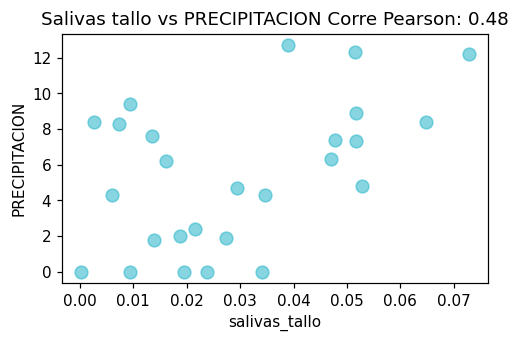

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.plot.scatter('salivas_tallo', 'PRECIPITACION', title= f'Salivas tallo vs PRECIPITACION Corre Pearson: {corrrel_SAL_PRE:.2}',
                     s = 70, alpha = 0.6, color = '#35bacc', figsize = (5,3));

**SCATER PLOT Y CORRELACION DE VARIABLES ADULTOS TALLO Vs PRECIPITACION**

**CORRELACION DE PEARSON**  (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)

In [ ]:
#CALCULAMOS EL COEFICIENTE DE CORRELACION DE PEARSON (QUE ASUME QUE LOS DATOS SE DISTRIBUYE NORMAL)
corrrel_ADU_PRE = DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo'].corr(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION']) # Método Pearson por defecto
print(corrrel_ADU_PRE)

0.5522417492833306


In [ ]:
correlacion_spearmanr_con_significancia(DATA_SALIVAZO_HUMEDAD_PRECIPITACION['adultos_tallo'], DATA_SALIVAZO_HUMEDAD_PRECIPITACION['PRECIPITACION'])

Coeficiente de correlación de Spearman: 0.42
Las muestras están correlacionadas (rechazar H0) p = 0.033


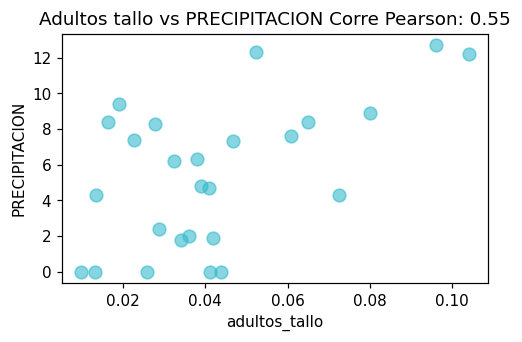

In [ ]:
DATA_SALIVAZO_HUMEDAD_PRECIPITACION.plot.scatter('adultos_tallo', 'PRECIPITACION', title= f'Adultos tallo vs PRECIPITACION Corre Pearson: {corrrel_ADU_PRE:.2}',
                     s = 70, alpha = 0.6, color = '#35bacc', figsize = (5,3));

# **Conclusion correlaciones de salivas y adultos vs precipitacion**

#### Observamos qu existe una correlacion entre la proliferacion de adultos con la precipitacion, del 0.55 y que tambien lo existe con las salivas del 0.48

#### Esto quiere decir que la plaga aumenta su poblacion en temporadas de altas precipitaciones.

# **5) Modelacion espacial**


#### Primero modelamos el mapa geografico de colombia y los puntos del monitoreo de plaga en estado larva y adulto ubicados en el valle del cauca.



In [ ]:
# Cargar archivo de datos geográficos de los municipios de Colombia.

# Primero necesitamos instalar la utilidad 'gdown' debido al tamaño del archivo:
!pip install --upgrade gdown

# Observe que la cadena "id=..." en la URL corresponde al ID del archivo de Drive que queremos descargar
!gdown https://drive.google.com/uc?id=1wMwLcKZ0v18Dwse0Ln1-GTimFHpgSlir

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.6.4
    Uninstalling gdown-4.6.4:
      Successfully uninstalled gdown-4.6.4
Downloading...
From (uriginal): https://drive.google.com/uc?id=1wMwLcKZ0v18Dwse0Ln1-GTimFHpgSlir
From (redirected): https://drive.google.com/uc?id=1wMwLcKZ0v18Dwse0Ln1-GTimFHpgSlir&confirm=t&uuid=2f7ce95b-a6c9-47c4-af17-86395524cec2
To: /content/colombia.zip
100% 50.2M/50.2M [00:00<00:00, 71.9MB/s]


In [ ]:
!unzip colombia.zip

Archive:  colombia.zip
  inflating: divipola_dpto_index.hdf  
  inflating: divipola_mun_index.hdf  
  inflating: shapes/Cabecera Municipal.dbf  
  inflating: shapes/Cabecera Municipal.prj  
  inflating: shapes/Cabecera Municipal.sbn  
  inflating: shapes/Cabecera Municipal.sbx  
  inflating: shapes/Cabecera Municipal.shp  
  inflating: shapes/Cabecera Municipal.shp.xml  
  inflating: shapes/Cabecera Municipal.shx  
  inflating: shapes/desktop.ini      
  inflating: shapes/Fuera colombia.dbf  
  inflating: shapes/Fuera colombia.prj  
  inflating: shapes/Fuera colombia.sbn  
  inflating: shapes/Fuera colombia.sbx  
  inflating: shapes/Fuera colombia.shp  
  inflating: shapes/Fuera colombia.shx  
  inflating: shapes/Limite Departamental.dbf  
  inflating: shapes/Limite Departamental.prj  
  inflating: shapes/Limite Departamental.sbn  
  inflating: shapes/Limite Departamental.sbx  
  inflating: shapes/Limite Departamental.shp  
  inflating: shapes/Limite Departamental.shp.xml  
  inflating

In [ ]:
col_mun = gpd.read_file(r"shapes/Limite Municipal.shp")       # Municipios
col_deps = gpd.read_file(r"shapes/Limite Departamental.shp")  # Departamentos

In [ ]:
gdf = gpd.GeoDataFrame(BD_SALIVAZO, geometry=gpd.points_from_xy(BD_SALIVAZO.Longitud, BD_SALIVAZO.Latitud))

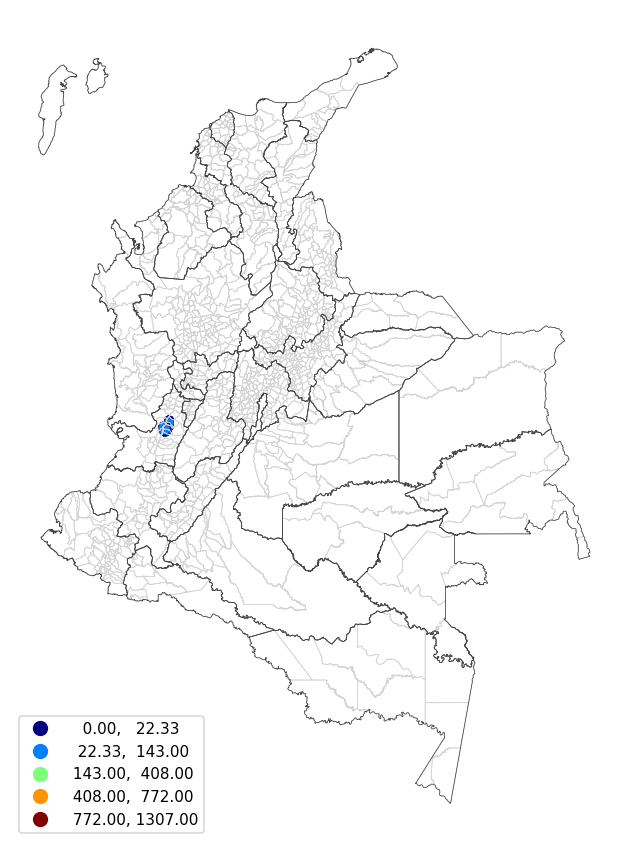

In [ ]:
#Mapa Colombia:

fig, ax = plt.subplots(1, figsize=(10, 10))       # Creamos la figura y el objeto Axes con Matplotlib.
ax.set_aspect('equal');
ax.set_axis_off();

gdf.plot(column="tallos_m",                    # Variable para representar en el mapa coroplético (área en kilómetros cuadrados).
             ax=ax,
             cmap='jet', linewidth=0.3,
             scheme='fisher_jenks',
             legend=True,                         # Habilitamos la leyenda.
             legend_kwds={'loc': 'lower left'});  # Definimos la posición del recuadro de leyenda abajo a la izquierda.

col_mun.geometry.boundary.plot(linewidth=0.5, edgecolor='lightgrey',
                                color=None, ax=ax);

col_deps.geometry.boundary.plot(linewidth=0.5, edgecolor='#444444',
                                color=None, ax=ax);

#### En el mapa podemos observar una leyenda que nos indica las presencias de la plaga en estado larva y adulto de los datos historicos desde el año 2009 al 2019.



In [ ]:
col_mun2=col_mun[col_mun['DEPARTAMEN']=='VALLE DEL CAUCA']

#### Reducimos la visualizacion y modelacion espacial solo al departamento del Valle del Cauca con todos sus municipios diferenciados.

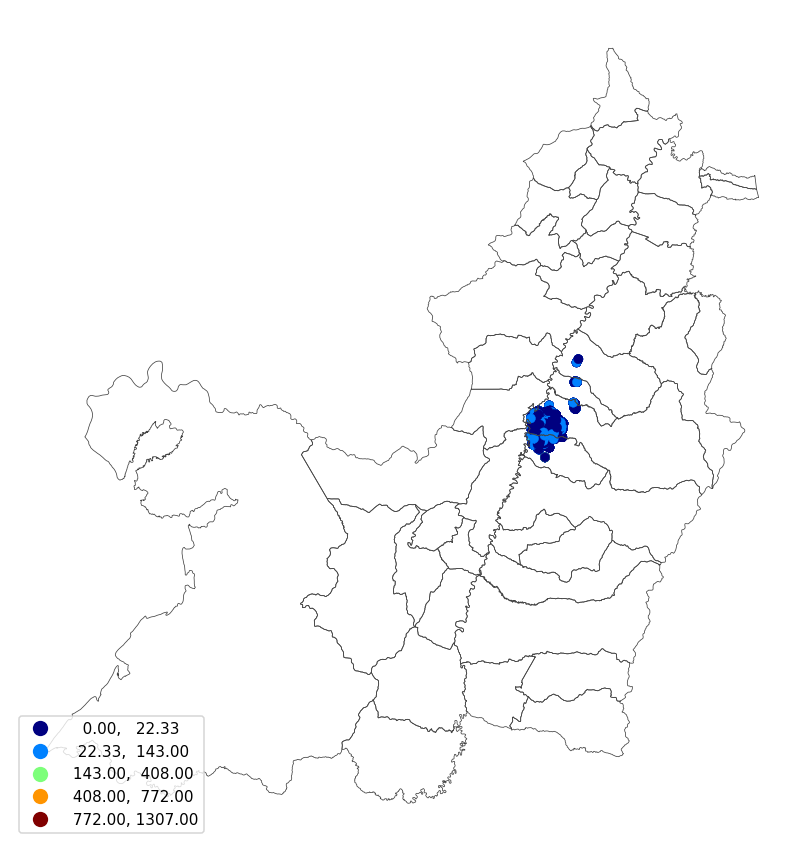

In [ ]:
#Mapa Valle del Cauca:

fig, ax = plt.subplots(1, figsize=(10, 10))       # Creamos la figura y el objeto Axes con Matplotlib.
ax.set_aspect('equal');
ax.set_axis_off();

gdf.plot(column="tallos_m",                    # Variable para representar en el mapa coroplético (área en kilómetros cuadrados).
             ax=ax,
             cmap='jet', linewidth=0.3,
             scheme='fisher_jenks',
             legend=True,                         # Habilitamos la leyenda.
             legend_kwds={'loc': 'lower left'});  # Definimos la posición del recuadro de leyenda abajo a la izquierda.


col_mun2.geometry.boundary.plot(linewidth=0.5, edgecolor='#444444',
                                color=None, ax=ax);

In [ ]:
col_mun3=col_mun2[col_mun2['NOMBRE_ENT']=='TULUÁ']

#### Para observar una mejor resolucion de los puntos, reducimos la visualizacion y modelacion espacial al municipio de Tulua, el mas cercano al ingenio de caña.

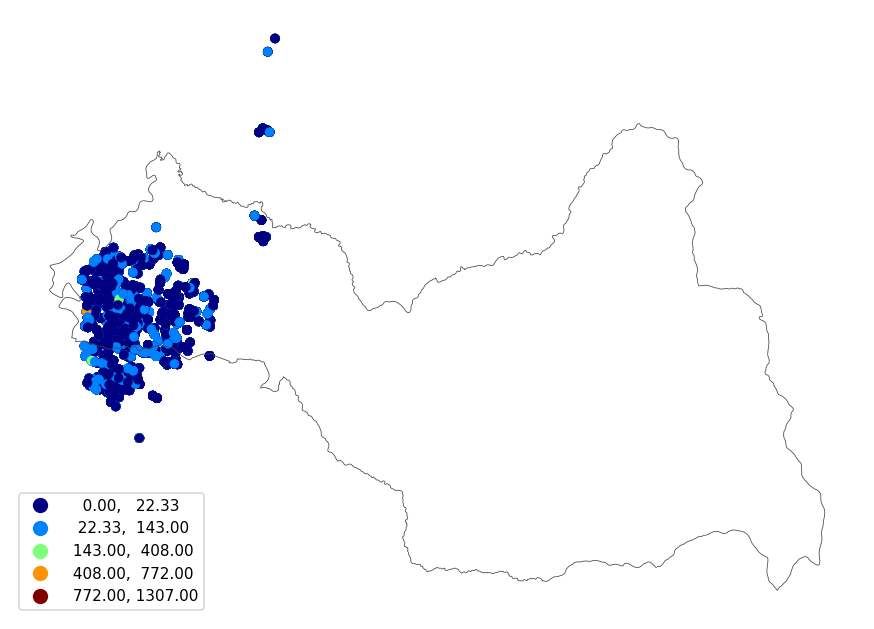

In [ ]:
#Mapa Tulua:

fig, ax = plt.subplots(1, figsize=(10, 10))       # Creamos la figura y el objeto Axes con Matplotlib.
ax.set_aspect('equal');
ax.set_axis_off();

gdf.plot(column="tallos_m",                    # Variable para representar en el mapa coroplético (área en kilómetros cuadrados).
             ax=ax,
             cmap='jet', linewidth=0.3,
             scheme='fisher_jenks',
             legend=True,                         # Habilitamos la leyenda.
             legend_kwds={'loc': 'lower left'});  # Definimos la posición del recuadro de leyenda abajo a la izquierda.

col_mun3.geometry.boundary.plot(linewidth=0.5, edgecolor='#444444',
                                color=None, ax=ax);

#### **MODELACION ESPACIAL DE SALIVAS Y ADULTOS EN EL INGENIO DE CAÑA DE AZUCAR SAN CARLOS A 2.5 KM DE TULUA, VALLE DEL CAUCA**

- #### Observamos que la mayoria de puntos de caracter azul oscuro nos informan presencias entre 0.0 a 22.33 insectos plaga en estado larva y adulto.

- #### Los puntos de caracter azul claro informan presencias entre 22.33 a 143.00 insectos plaga.

- #### Se observan dos puntos verde con alta probabilidad de presencia entre 143.00 a 408.00 presencias del insecto plaga.

- #### Existe un unico punto de caracter naranja que informa presencia de 408.00 a 772.00; se puede considerar como el punto mas critico de las 6000 hectareas en el ingenio de caña de azucar.